In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import arff
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay
)

!wget -O asd_children.zip "https://archive.ics.uci.edu/static/public/419/autistic+spectrum+disorder+screening+data+for+children.zip"
!unzip -o asd_children.zip
!ls

from scipy.io import arff
import pandas as pd

data, meta = arff.loadarff('Autism-Child-Data.arff')
df = pd.DataFrame(data)

df.head()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.decode('utf-8')

df.head()

df['Class/ASD'].value_counts()

df['Class/ASD'] = df['Class/ASD'].map({'NO': 0, 'YES': 1})

df['Class/ASD'].value_counts()

--2026-04-02 19:12:17--  https://archive.ics.uci.edu/static/public/419/autistic+spectrum+disorder+screening+data+for+children.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘asd_children.zip’

asd_children.zip        [ <=>                ]  39.14K  --.-KB/s    in 0.06s   

2026-04-02 19:12:18 (677 KB/s) - ‘asd_children.zip’ saved [40081]

Archive:  asd_children.zip
  inflating: Autism-Child-Data.arff  
  inflating: Autism-Screening-Child-Data Description.docx  
 asd_children.zip				 fig1_distribuicao_classes.png
 Autism-Child-Data.arff				 sample_data
'Autism-Screening-Child-Data Description.docx'


,count
Class/ASD,
0,151
1,141


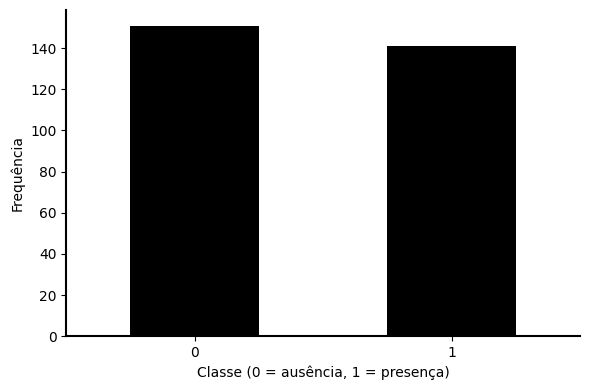

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df["Class/ASD"].value_counts().sort_index().plot(kind="bar", color="black")

plt.xlabel("Classe (0 = ausência, 1 = presença)")
plt.ylabel("Frequência")

plt.xticks(rotation=0)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.grid(False)

plt.tight_layout()
plt.savefig("fig1.png", dpi=300)
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

X.isna().sum().sort_values(ascending=False).head(10)

X = X.fillna(0)

X.columns

X = X.drop('result', axis=1)

X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


Treino: (204, 82)
Teste: (88, 82)


In [9]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))



Accuracy: 0.9886363636363636


In [10]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        51
           1       1.00      0.97      0.99        37

    accuracy                           0.99        88
   macro avg       0.99      0.99      0.99        88
weighted avg       0.99      0.99      0.99        88



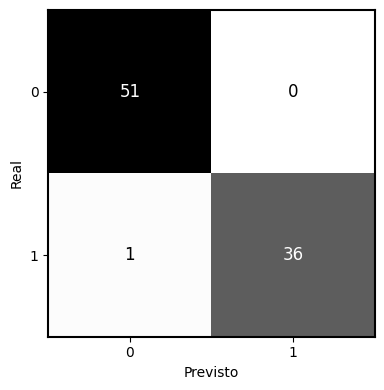

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Greys")

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max()/2 else "black"
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color=color, fontsize=12)

plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
plt.xlabel("Previsto")
plt.ylabel("Real")

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.savefig("fig2.png", dpi=300)
plt.show()


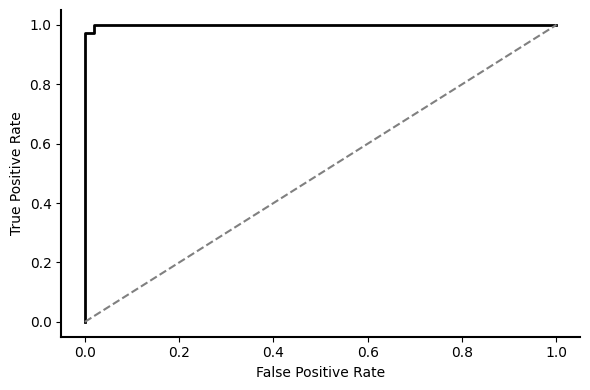

AUC Logística: 0.9994700582935877


In [14]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color="black", linewidth=2)
plt.plot([0,1],[0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.grid(False)

plt.tight_layout()
plt.savefig("fig3.png", dpi=300)
plt.show()

print("AUC Logística:", roc_auc)


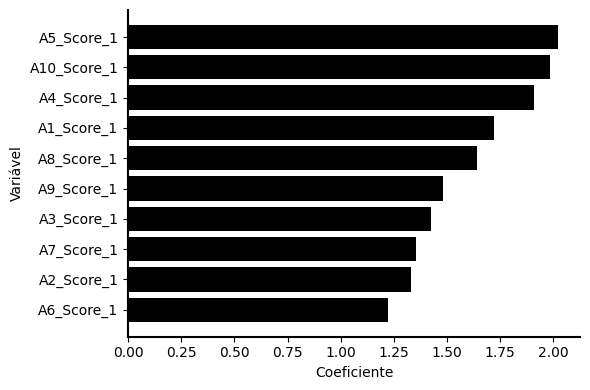

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

coef = model.coef_[0]
features = X.columns

coef_df = pd.DataFrame({
    "Variável": features,
    "Coeficiente": coef
})

coef_df["Importância"] = np.abs(coef_df["Coeficiente"])
coef_df = coef_df.sort_values("Importância", ascending=False)

top = coef_df.head(10)

plt.figure(figsize=(6,4))
plt.barh(top["Variável"], top["Coeficiente"], color="black")

plt.xlabel("Coeficiente")
plt.ylabel("Variável")

plt.gca().invert_yaxis()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.grid(False)

plt.tight_layout()
plt.savefig("fig4.png", dpi=300)
plt.show()


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", rf.score(X_test, y_test))

from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

plt.figure()


Random Forest Accuracy: 0.9090909090909091
              precision    recall  f1-score   support

           0       0.96      0.88      0.92        51
           1       0.85      0.95      0.90        37

    accuracy                           0.91        88
   macro avg       0.91      0.91      0.91        88
weighted avg       0.91      0.91      0.91        88



<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

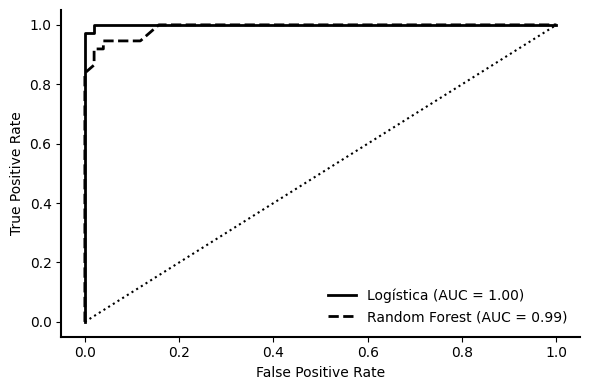

In [31]:
plt.figure(figsize=(6,4))

plt.plot(fpr_lr, tpr_lr, color="black", linewidth=2, linestyle="-")
plt.plot(fpr_rf, tpr_rf, color="black", linewidth=2, linestyle="--")
plt.plot([0,1],[0,1], linestyle=":", color="black")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.grid(False)

plt.legend([
    f"Logística (AUC = {auc_lr:.2f})",
    f"Random Forest (AUC = {auc_rf:.2f})"
], frameon=False)

plt.tight_layout()
plt.savefig("fig5.png", dpi=300)
plt.show()

In [ ]:
tab_abs = pd.crosstab(df["gender"], df["Class/ASD"])
tab_pct = pd.crosstab(df["gender"], df["Class/ASD"], normalize="index") * 100

tab_abs, tab_pct

(Class/ASD    0    1
 gender             
 f           46   38
 m          105  103,
 Class/ASD          0          1
 gender                         
 f          54.761905  45.238095
 m          50.480769  49.519231)

<Figure size 600x400 with 0 Axes>

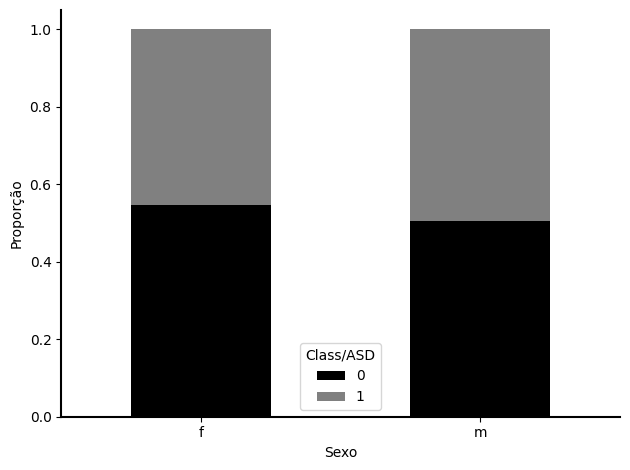

In [25]:
tab = pd.crosstab(df["gender"], df["Class/ASD"], normalize="index")

plt.figure(figsize=(6,4))
tab.plot(kind="bar", stacked=True, color=["black","gray"])

plt.xlabel("Sexo")
plt.ylabel("Proporção")

plt.xticks(rotation=0)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.grid(False)

plt.tight_layout()
plt.savefig("fig6.png", dpi=300)
plt.show()

In [29]:
import pandas as pd
from scipy.stats import chi2_contingency


tab_abs = pd.crosstab(df["gender"], df["Class/ASD"])

chi2, p, dof, expected = chi2_contingency(tab_abs)

print("Qui-quadrado:", chi2)
print("p-valor:", p)


Qui-quadrado: 0.28447044555963774
p-valor: 0.5937859868520012
